# 01 — Entendendo as bags e o forward pass

Jornada deste notebook:

1. **Ver o conjunto** (MNIST-bags): o que é uma bag, o que tem dentro, como acesso cada informação.
2. **Uma bag atravessando a rede**, passo a passo, com os *shapes* em cada etapa: imagem → encoder → embeddings → agregador → vetor da bag → head → saída.
3. **Interpretabilidade**: onde a `instance_localization_auc` entra.

> MNIST-bags é o único dataset 100%% visual (dá pra *ver* os dígitos) e baixa sozinho. MUSK/animais entram depois.

In [2]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt

from hopmil.data.mnist_bags import MNISTBags
from hopmil.models import CNNEncoder, build_aggregator, MILClassifier
from hopmil.eval.metrics import instance_localization_auc

torch.manual_seed(0)
print('torch', torch.__version__)

torch 2.12.1+cpu


## Parte 1 — Ver o conjunto

Cada **bag** é um conjunto de dígitos MNIST. A bag é **positiva** se contém pelo menos um dígito-alvo (aqui, o `9`). Carregamos um conjunto pequeno só para inspecionar.

In [3]:
ds = MNISTBags(root='../data/raw', train=True, target_digit=9,
               mean_bag_size=8, var_bag_size=2, num_bags=50, seed=0)

labels = [int(b.label) for b in ds.bags]
sizes = [b.instances.shape[0] for b in ds.bags]
print(f'n bags          : {len(ds)}')
print(f'positivas       : {sum(labels)}  |  negativas: {len(labels) - sum(labels)}')
print(f'tam. de bag     : min={min(sizes)}  max={max(sizes)}  media={sum(sizes)/len(sizes):.1f}')

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.75MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 207kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.74MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


n bags          : 50
positivas       : 26  |  negativas: 24
tam. de bag     : min=4  max=15  media=8.1


### Anatomia de UMA bag

Os três atributos do objeto `Bag` e como acessá-los:

| Atributo | Shape | O que é |
|---|---|---|
| `bag.instances` | `(n, 1, 28, 28)` | as `n` imagens (instâncias) da bag |
| `bag.label` | escalar | rótulo da bag (1 se tem algum `9`) |
| `bag.instance_labels` | `(n,)` | 1 para cada instância que É o `9` (só existe no sintético) |

In [4]:
# pega a primeira bag POSITIVA para o exemplo ser interessante
bag = next(b for b in ds.bags if int(b.label) == 1)

print('bag.instances       ->', tuple(bag.instances.shape))
print('bag.label           ->', bag.label.item())
print('bag.instance_labels ->', bag.instance_labels.tolist())
print()
print('n instancias        :', bag.instances.shape[0])
print('quais sao o alvo (9):', (bag.instance_labels == 1).nonzero().squeeze(-1).tolist())

bag.instances       -> (6, 1, 28, 28)
bag.label           -> 1
bag.instance_labels -> [0, 0, 0, 0, 1, 0]

n instancias        : 6
quais sao o alvo (9): [4]


### Visualizar a bag
Desenhamos cada instância; em vermelho, as que são o dígito-alvo (`9`).

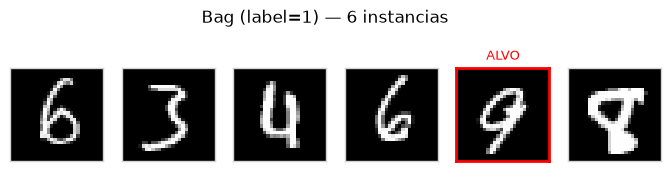

In [5]:
imgs = bag.instances.squeeze(1) * 0.3081 + 0.1307  # desfaz a normalizacao p/ exibir
n = imgs.shape[0]
fig, axes = plt.subplots(1, n, figsize=(1.4 * n, 1.6))
for i, ax in enumerate(axes):
    is_target = bag.instance_labels[i].item() == 1
    ax.imshow(imgs[i], cmap='gray')
    ax.set_title('ALVO' if is_target else '', color='red', fontsize=9)
    for s in ax.spines.values():
        s.set_color('red' if is_target else 'lightgray')
        s.set_linewidth(2 if is_target else 1)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'Bag (label={bag.label.item()}) — {n} instancias', y=1.15)
plt.show()

## Parte 2 — Uma bag atravessando a rede

Montamos os 3 blocos (encoder fixo, agregador trocável, head fixo) e passamos a bag **etapa por etapa**, imprimindo o shape em cada ponto:

```
(n,1,28,28) --encoder--> (n,128) --agregador--> (128,) + weights(n,) --head--> (1,) -> prob
```

In [6]:
DIM = 128
encoder = CNNEncoder(dim=DIM)
aggregator = build_aggregator('attention', dim=DIM)   # troque por 'mean' / 'max' / 'hopfield'
clf = MILClassifier(encoder=encoder, aggregator=aggregator, num_classes=1, dim=DIM)
clf.eval()
print(clf)

MILClassifier(
  (encoder): CNNEncoder(
    (features): Sequential(
      (0): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1))
      (4): ReLU(inplace=True)
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=800, out_features=128, bias=True)
      (2): ReLU(inplace=True)
    )
  )
  (aggregator): AttentionMIL(
    (V): Linear(in_features=128, out_features=128, bias=True)
    (U): Linear(in_features=128, out_features=128, bias=True)
    (w): Linear(in_features=128, out_features=1, bias=True)
  )
  (head): Linear(in_features=128, out_features=1, bias=True)
)


In [7]:
with torch.no_grad():
    x = bag.instances                       # entrada crua
    print('1) entrada (instancias) :', tuple(x.shape))

    emb = encoder(x)                        # embeddings no MEIO
    print('2) apos o encoder       :', tuple(emb.shape), '  <- 1 vetor por instancia')

    z, w = aggregator(emb)                  # agregacao
    print('3) vetor da bag (z)     :', tuple(z.shape), '  <- a bag inteira virou 1 vetor')
    print('   weights (w)          :', None if w is None else tuple(w.shape), '  <- peso por instancia')

    logit = clf.head(z)                     # classificador
    prob = torch.sigmoid(logit)
    print('4) logit                :', tuple(logit.shape), '->', round(logit.item(), 3))
    print('5) probabilidade (saida):', round(prob.item(), 3))

1) entrada (instancias) : (6, 1, 28, 28)
2) apos o encoder       : (6, 128)   <- 1 vetor por instancia
3) vetor da bag (z)     : (128,)   <- a bag inteira virou 1 vetor
   weights (w)          : (6,)   <- peso por instancia
4) logit                : (1,) -> 0.075
5) probabilidade (saida): 0.519


O mesmo, em uma chamada (é o que o treino usa) — note que `MILClassifier` recebe uma **lista de bags** e devolve `(logits, lista_de_weights)`:

In [8]:
with torch.no_grad():
    logits, attns = clf([bag.instances])    # batch de 1 bag
print('logits :', tuple(logits.shape), '->', round(logits.item(), 3))
print('weights:', tuple(attns[0].shape))

logits : (1, 1) -> 0.075
weights: (6,)


## Parte 3 — Interpretabilidade (onde a métrica entra)

`instance_localization_auc(weights, instance_labels)` mede se os pesos do agregador **apontam para as instâncias-alvo**. Ela só se aplica aqui porque o MNIST-bags tem `instance_labels`.

> A rede está **sem treino** (pesos aleatórios), então a AUC vai ficar perto do acaso (~0.5). Depois de treinar, esperamos que suba — é exatamente isso que vamos comparar entre os 4 agregadores.

In [9]:
auc = instance_localization_auc(w, bag.instance_labels)
print(f'localizacao AUC (sem treino): {auc:.3f}')
print()
order = torch.argsort(w, descending=True)
print('instancias ordenadas por peso de atencao:')
for rank, i in enumerate(order.tolist()):
    flag = '  <-- ALVO (9)' if bag.instance_labels[i].item() == 1 else ''
    print(f'  #{rank+1}  inst {i:2d}  peso={w[i].item():.3f}{flag}')

localizacao AUC (sem treino): 0.200

instancias ordenadas por peso de atencao:
  #1  inst  1  peso=0.170
  #2  inst  0  peso=0.169
  #3  inst  3  peso=0.167
  #4  inst  2  peso=0.166
  #5  inst  4  peso=0.164  <-- ALVO (9)
  #6  inst  5  peso=0.163


## Próximos passos

- Trocar `aggregator` por `'mean'`/`'max'` (verá `weights = None`) e por `'hopfield'` (requer `uv sync --extra hopfield`).
- Plugar os datasets tabulares (MUSK, fox/elephant/tiger) com o `MLPEncoder`.
- Fechar o `training/train.py` para treinar de verdade e rodar a comparação no Kaggle.